In [ ]:
import torch

# si ringrazia la gentile partecipazione del server Linux per la generazione del dataset (METIS non funziona su Windows)
#dataset = RedditSubGraphDataset(path='Reddit', num_graphs=1000, task_type='b')

dataset = torch.load("reddit_task3_clusters_b.pt", weights_only=False)

In [2]:
#raccogliamo tutti gli ID unici originali presenti nel dataset
id_originali = set()
for split in ['train', 'val', 'test']:
    for subgraph in dataset[split]:
        id_originali.add(subgraph.y.item())

#ordiniamo gli ID per avere una mappatura 
id_originali = sorted(list(id_originali))
num_classi_reali = len(id_originali)

#creiamo un dizionario di conversione
mappa_id = {id_vecchio: id_nuovo for id_nuovo, id_vecchio in enumerate(id_originali)}

print(f"Community uniche trovate: {num_classi_reali}")

# applichiamo la rimappatura a tutti i sotto-grafi del dataset
for split in ['train', 'val', 'test']:
    for subgraph in dataset[split]:
        id_vecchio = subgraph.y.item()
        id_nuovo = mappa_id[id_vecchio]
        
        #sovrascriviamo il target con il nuovo indice compresso (da 0 a 39)
        subgraph.y = torch.tensor(id_nuovo, dtype=torch.long)

print("\n[OK] Rimappatura completata!")

Community uniche trovate: 39

[OK] Rimappatura completata!


In [3]:
from torch_geometric.loader import DataLoader

train_loader = DataLoader(dataset["train"], batch_size=128, shuffle=True)
val_loader = DataLoader(dataset["val"], batch_size=128, shuffle=False)
test_loader = DataLoader(dataset["test"], batch_size=128, shuffle=False)

In [4]:
import numpy as np
from collections import Counter
from utils_task3_b import train_loop
from utils_task3_b import GCNClassifier,evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr = 2e-4
epochs = 50

#estraiamo tutte le etichette dal train set
train_labels = [subgraph.y.item() for subgraph in dataset['train']]
conteggio_classi = Counter(train_labels)

num_classi = len(set(train_labels))

#formula del bilanciamento multi-classe: total_samples / (num_classes * class_samples)
totale_campioni = len(train_labels)
pesi_array = np.zeros(num_classi, dtype=np.float32)

for t in range(num_classi):
        pesi_array[t] = totale_campioni / (num_classi * conteggio_classi[t])


#convertiamo il vettore dei pesi in tensore
ce_weights = torch.tensor(pesi_array, dtype=torch.float32).to(device)

print(f"Task B - Classi rilevate: {num_classi}")

model = GCNClassifier(
    in_channels=dataset['train'][0].num_features, 
    hidden_channels=256, 
    out_channels=num_classi
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=ce_weights)
best_model_path = "best_model_task3_b_GCN.pth"
scaler = torch.amp.GradScaler()

# Lancio dell'addestramento
history = train_loop(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    loss_fn, 
    device, 
    epochs, 
    best_model_path, 
    scaler,
    patience=5
)

Task B - Classi rilevate: 39


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 18.52it/s]


Epoch 1/50 - Train Loss: 3.6065 - Val Loss: 3.5380 - Balanced Accuracy: 0.1882 - F1 Score: 0.1657
Nuovo miglior modello salvato con Val Loss: 3.5380
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 35.18it/s]


Epoch 2/50 - Train Loss: 3.4614 - Val Loss: 3.3882 - Balanced Accuracy: 0.2548 - F1 Score: 0.2248
Nuovo miglior modello salvato con Val Loss: 3.3882
-----------------------------------------------


...

Epoch 48/50 - Train Loss: 0.1057 - Val Loss: 0.2249 - Balanced Accuracy: 0.9231 - F1 Score: 0.9474
Nessun miglioramento. Contatore di pazienza: 1/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 34.71it/s]


Epoch 49/50 - Train Loss: 0.1055 - Val Loss: 0.2252 - Balanced Accuracy: 0.9237 - F1 Score: 0.9444
Nessun miglioramento. Contatore di pazienza: 2/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 34.91it/s]

Epoch 50/50 - Train Loss: 0.1036 - Val Loss: 0.2172 - Balanced Accuracy: 0.9087 - F1 Score: 0.9362
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


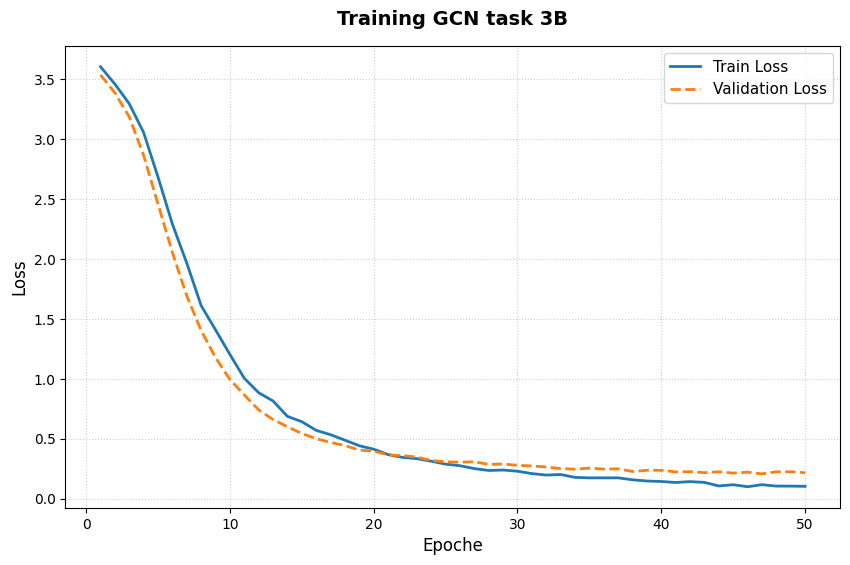

In [5]:
from utils_task1 import plot_history

plot_history(history,"Training GCN task 3B")

In [6]:
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model,test_loader,loss_fn,device)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
torch.cuda.empty_cache()

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  4.96it/s]

Test Loss: 0.2595 - Balanced Accuracy: 0.9144 - F1 Score: 0.9452


Tentativo SAGE

In [7]:
from utils_task3_b import SAGEClassifier, train_loop, evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr = 2e-4
epochs = 50

model = SAGEClassifier(
    in_channels=dataset['train'][0].num_features, 
    hidden_channels=256, 
    out_channels=num_classi
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=ce_weights)
best_model_path = "best_model_task3_b_SAGE.pth"
scaler = torch.amp.GradScaler()

# Lancio dell'addestramento
history = train_loop(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    loss_fn, 
    device, 
    epochs, 
    best_model_path, 
    scaler,
    patience=5
)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 39.53it/s]


Epoch 1/50 - Train Loss: 3.6122 - Val Loss: 3.5242 - Balanced Accuracy: 0.2841 - F1 Score: 0.2416
Nuovo miglior modello salvato con Val Loss: 3.5242
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 36.94it/s]


Epoch 2/50 - Train Loss: 3.4305 - Val Loss: 3.3136 - Balanced Accuracy: 0.3255 - F1 Score: 0.2929
Nuovo miglior modello salvato con Val Loss: 3.3136
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 40.05it/s]


...

Epoch 43/50 - Train Loss: 0.1130 - Val Loss: 0.2484 - Balanced Accuracy: 0.9066 - F1 Score: 0.9305
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 37.61it/s]


Epoch 44/50 - Train Loss: 0.1045 - Val Loss: 0.2430 - Balanced Accuracy: 0.9235 - F1 Score: 0.9391
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 38.13it/s]

Epoch 45/50 - Train Loss: 0.0942 - Val Loss: 0.2431 - Balanced Accuracy: 0.9295 - F1 Score: 0.9466
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


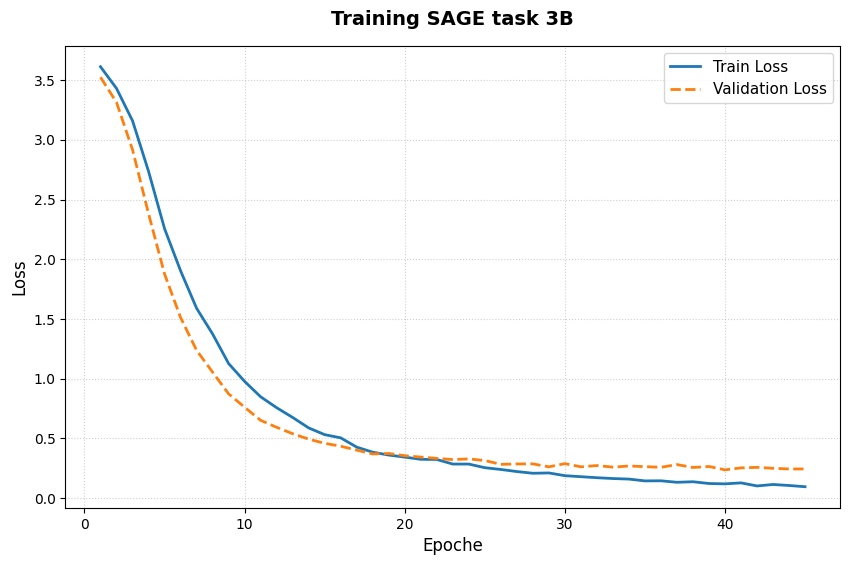

In [8]:
from utils_task1 import plot_history

plot_history(history, "Training SAGE task 3B")

In [9]:
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model, test_loader, loss_fn, device)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
torch.cuda.empty_cache()

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  6.67it/s]

Test Loss: 0.2288 - Balanced Accuracy: 0.9097 - F1 Score: 0.9371


Tentativo GAT

In [10]:
from utils_task3_b import GATv2Classifier, train_loop, evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr = 2e-4
epochs = 50

model = GATv2Classifier(
    in_channels=dataset['train'][0].num_features, 
    hidden_channels=256, 
    out_channels=num_classi
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=ce_weights)
best_model_path = "best_model_task3_b_GAT.pth"
scaler = torch.amp.GradScaler()

# Lancio dell'addestramento
history = train_loop(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    loss_fn, 
    device, 
    epochs, 
    best_model_path, 
    scaler,
    patience=5
)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 15.47it/s]


Epoch 1/50 - Train Loss: 3.6400 - Val Loss: 3.5875 - Balanced Accuracy: 0.1594 - F1 Score: 0.1337
Nuovo miglior modello salvato con Val Loss: 3.5875
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 10.00it/s]


Epoch 2/50 - Train Loss: 3.5074 - Val Loss: 3.4431 - Balanced Accuracy: 0.2396 - F1 Score: 0.2263
Nuovo miglior modello salvato con Val Loss: 3.4431
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  8.69it/s]


...

Epoch 32/50 - Train Loss: 0.3255 - Val Loss: 0.9026 - Balanced Accuracy: 0.7861 - F1 Score: 0.8168
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 10.07it/s]


Epoch 33/50 - Train Loss: 0.3034 - Val Loss: 0.9554 - Balanced Accuracy: 0.7678 - F1 Score: 0.7985
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  8.32it/s]

Epoch 34/50 - Train Loss: 0.2957 - Val Loss: 0.9350 - Balanced Accuracy: 0.7844 - F1 Score: 0.8137
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


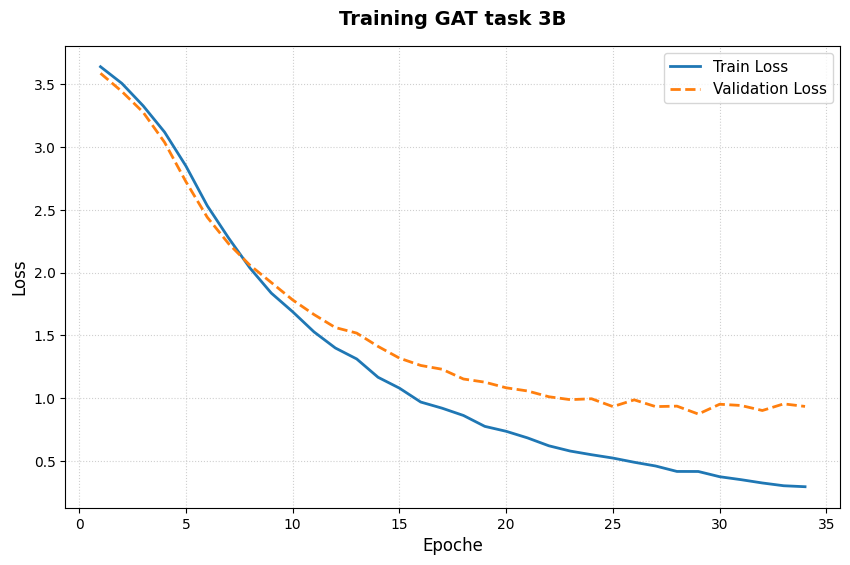

In [11]:
from utils_task1 import plot_history

plot_history(history, "Training GAT task 3B")

In [12]:
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model, test_loader, loss_fn, device)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
torch.cuda.empty_cache()

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  5.76it/s]


Test Loss: 0.7481 - Balanced Accuracy: 0.8137 - F1 Score: 0.8178


Tentativo GIN

In [14]:
from utils_task3_b import FlatGINClassifier, train_loop, evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr = 2e-4
epochs = 50

model = FlatGINClassifier(
    in_channels=dataset['train'][0].num_features, 
    hidden_channels=256, 
    out_channels=num_classi
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=ce_weights)
best_model_path = "best_model_task3_b_GIN.pth"
scaler = torch.amp.GradScaler()

# Lancio dell'addestramento
history = train_loop(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    loss_fn, 
    device, 
    epochs, 
    best_model_path, 
    scaler,
    patience=5
)

Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 26.97it/s]


Epoch 1/50 - Train Loss: 3.3856 - Val Loss: 3.3713 - Balanced Accuracy: 0.2864 - F1 Score: 0.2844
Nuovo miglior modello salvato con Val Loss: 3.3713
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 29.92it/s]


Epoch 2/50 - Train Loss: 2.8979 - Val Loss: 2.9765 - Balanced Accuracy: 0.3774 - F1 Score: 0.4295
Nuovo miglior modello salvato con Val Loss: 2.9765
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 26.72it/s]


...

Epoch 40/50 - Train Loss: 0.1116 - Val Loss: 0.4100 - Balanced Accuracy: 0.9082 - F1 Score: 0.9365
Nessun miglioramento. Contatore di pazienza: 3/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 34.33it/s]


Epoch 41/50 - Train Loss: 0.1007 - Val Loss: 0.4077 - Balanced Accuracy: 0.9018 - F1 Score: 0.9324
Nessun miglioramento. Contatore di pazienza: 4/5
-----------------------------------------------


Evaluating...: 100%|██████████| 2/2 [00:00<00:00, 33.34it/s]

Epoch 42/50 - Train Loss: 0.1002 - Val Loss: 0.4134 - Balanced Accuracy: 0.9082 - F1 Score: 0.9365
Nessun miglioramento. Contatore di pazienza: 5/5
Early stopping attivato.


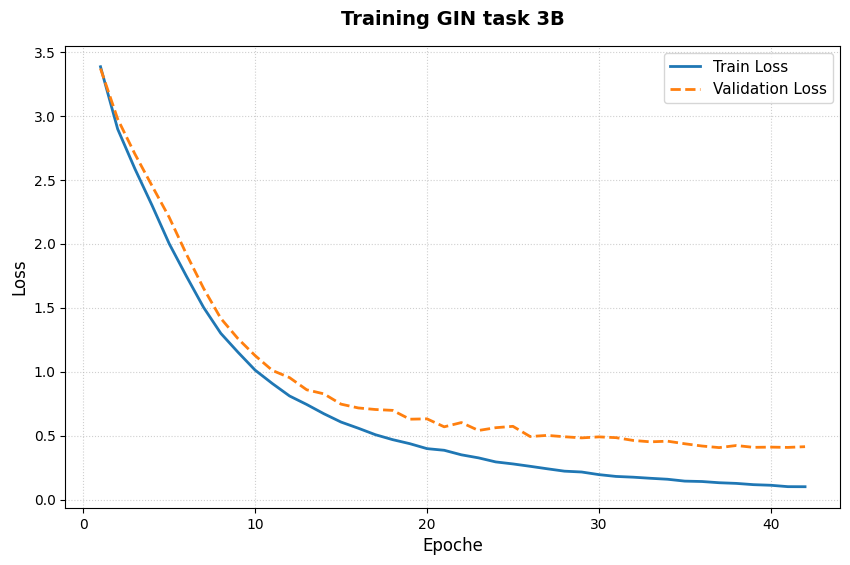

In [15]:
from utils_task1 import plot_history

plot_history(history, "Training GIN task 3B")

In [16]:
print("Valutazione sul test set")
model.load_state_dict(torch.load(best_model_path))
test_metrics = evaluate(model, test_loader, loss_fn, device)
print(f"Test Loss: {test_metrics['val_loss']:.4f} - Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f} - F1 Score: {test_metrics['f1_score']:.4f}")
torch.cuda.empty_cache()

Valutazione sul test set


Evaluating...: 100%|██████████| 2/2 [00:00<00:00,  4.41it/s]

Test Loss: 0.6175 - Balanced Accuracy: 0.9017 - F1 Score: 0.9325
